# Graph Neural Networks for MS Brain Network Classification

**Authors:** Gerard Asbert, Marina Rosell

## Assignment Overview

As mentioned in the exercise formulation, in this notebook we implemented the analysis on Multiple Sclerosis (MS) patients using three different approaches:
1. **Part 1:** Traditional Graph Learning Approach
2. **Part 2:** Graph Convolutional Networks (GCNs)
3. **Part 3:** Graph Attention Networks (GATs)

We will classify the subjects into two categories: Healthy Volunteers (HV) and People with Multiple Sclerosis (pwMS) using brain connectivity matrices derived from MRI imaging (DTI-FA, GM, and RS-fMRI).

### Dataset Description
- **Total Subjects:** 165 (147 MS patients, 18 healthy volunteers)
- **Brain Regions (Nodes):** 76
- **Connectivity Matrices:** 3 types (FA, GM, RS)
- **Classification:** Binary (HV vs pwMS)

As seen in the dataset description, the classes are heavily unbalanced. This will be a major problem throughout the whole project.

### Additional Features
- Data augmentation through brain region flipping
- Feature extraction using graph metrics
- Three machine learning approaches as a baseline comparison
- Comprehensive performance metrics (AUC-ROC, F1-score, Confusion Matrix)

### pip library installation (IMPORTANT: Run this on a new environment!) 

In [20]:
# Install required packages
import subprocess
import sys

# Define required packages
packages = [
    'torch',
    'torch-geometric',
    'scikit-learn',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'networkx',
    'imbalanced-learn'
]

print("Installing required packages...")
for package in packages:
    try:
        __import__(package.replace('-', '_'))
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
        print(f"✓ {package} installed successfully")

print("\nAll packages installed!")
print("\n" + "="*50)
print("PACKAGE VERSIONS:")
print("="*50)

import torch
import torch_geometric
import sklearn
import pandas
import numpy
import matplotlib
import seaborn
import networkx
import imblearn

print(f"PyTorch: {torch.__version__}")
print(f"PyTorch Geometric: {torch_geometric.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Pandas: {pandas.__version__}")
print(f"NumPy: {numpy.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Seaborn: {seaborn.__version__}")
print(f"NetworkX: {networkx.__version__}")
print(f"Imbalanced-learn: {imblearn.__version__}")

Installing required packages...
✓ torch already installed
✓ torch-geometric already installed
Installing scikit-learn...
✓ scikit-learn installed successfully
✓ pandas already installed
✓ numpy already installed
✓ matplotlib already installed
✓ seaborn already installed
✓ networkx already installed
Installing imbalanced-learn...
✓ imbalanced-learn installed successfully

All packages installed!

PACKAGE VERSIONS:
PyTorch: 2.2.2+cu121
PyTorch Geometric: 2.7.0
Scikit-learn: 1.7.2
Pandas: 2.3.3
NumPy: 1.26.4
Matplotlib: 3.10.8
Seaborn: 0.13.2
NetworkX: 3.4.2
Imbalanced-learn: 0.14.1


## Section 0: Data Loading and Preprocessing

In this section we load and prepares the MS brain network dataset.

In [21]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import torch
import torch.nn as torch_nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, 
                             confusion_matrix, roc_curve, precision_recall_curve, 
                             average_precision_score, classification_report)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Define base paths
basepath = "./data"
basepath_FA = os.path.join(basepath, "FA")
basepath_GM = os.path.join(basepath, "GM")
basepath_RS = os.path.join(basepath, "RS")

# Verify data exists
if not os.path.exists(basepath):
    raise FileNotFoundError(f"Data directory not found at {basepath}")

print("Data paths configured successfully!")
print(f"FA path: {basepath_FA}")
print(f"GM path: {basepath_GM}")
print(f"RS path: {basepath_RS}")

Data paths configured successfully!
FA path: ./data/FA
GM path: ./data/GM
RS path: ./data/RS


In [22]:
# Load demographics and define class constants
df_demographics = pd.read_csv(os.path.join(basepath, "demographics.csv"))
print("Demographics data shape:", df_demographics.shape)
print("\nMS type distribution:")
print(df_demographics["mstype"].value_counts().sort_index())
print("\nFirst few rows:")
print(df_demographics.head())

# Define class constants
CT_CONTROL = -1  # Healthy Volunteer
CT_RRMS = 0      # Relapsing-Remitting MS
CT_SPMS = 1      # Secondary Progressive MS
CT_PPMS = 2      # Primary Progressive MS

# Extract target labels and convert to binary classification (HV vs pwMS)
target = df_demographics["mstype"].values.copy()
target_binary = (target != CT_CONTROL).astype(int)  # 0: HV, 1: pwMS

print(f"\nBinary classification distribution:")
print(f"  Healthy Volunteers (HV): {(target_binary == 0).sum()}")
print(f"  People with MS (pwMS): {(target_binary == 1).sum()}")
print(f"  Proportion of pwMS: {(target_binary == 1).sum() / len(target_binary):.2%}")

Demographics data shape: (165, 2)

MS type distribution:
mstype
-1     18
 0    125
 1     16
 2      6
Name: count, dtype: int64

First few rows:
   id  mstype
0   0       1
1   1       2
2   2       0
3   3       0
4   4       0

Binary classification distribution:
  Healthy Volunteers (HV): 18
  People with MS (pwMS): 147
  Proportion of pwMS: 89.09%


As commented previously, the two classes are heavily unbalanced (89.09% of instances come from one class)

In [23]:
# Create filenames list
filenames = ["{:04d}.csv".format(x) for x in df_demographics["id"]]
print(f"Total subjects: {len(filenames)}")
print(f"First 5 filenames: {filenames[:5]}")

# Load all adjacency matrices into a 4D array
# Shape: (num_subjects=165, num_nodes=76, num_nodes=76, num_matrices=3)
print("\nLoading adjacency matrices...")
data = np.zeros(shape=(len(filenames), 76, 76, 3))

for i, filename in enumerate(filenames):
    if (i + 1) % 30 == 0:
        print(f"  Loaded {i+1}/{len(filenames)} subjects")
    
    # Load DTI-FA
    df = pd.read_csv(os.path.join(basepath_FA, filename), header=None)
    data[i, :, :, 0] = df.values
    
    # Load GM
    df = pd.read_csv(os.path.join(basepath_GM, filename), header=None)
    data[i, :, :, 1] = df.values
    
    # Load RS-fMRI
    df = pd.read_csv(os.path.join(basepath_RS, filename), header=None)
    data[i, :, :, 2] = df.values

print(f"\nData array shape: {data.shape}")
print(f"Data type: {data.dtype}")

# Compute basic statistics
print("\nData Statistics:")
print(f"  Min value: {data.min():.6f}")
print(f"  Max value: {data.max():.6f}")
print(f"  Mean value: {data.mean():.6f}")
print(f"  Std value: {data.std():.6f}")

Total subjects: 165
First 5 filenames: ['0000.csv', '0001.csv', '0002.csv', '0003.csv', '0004.csv']

Loading adjacency matrices...
  Loaded 30/165 subjects
  Loaded 60/165 subjects
  Loaded 90/165 subjects
  Loaded 120/165 subjects
  Loaded 150/165 subjects

Data array shape: (165, 76, 76, 3)
Data type: float64

Data Statistics:
  Min value: 0.000000
  Max value: 1.000000
  Mean value: 0.197489
  Std value: 0.199743


## Section 1: Data Augmentation

Given we are working with medical imaging, data augmentation is specially important given the inherent lack of samples in the field. We implement brain region flipping based on brain symmetry to augment the dataset. To try to fight the class imbalance, we will just apply this flipping to the missrepresented class of healthy volunteers.


In [38]:
# Define brain region permutations for symmetry-based flipping
# Based on brain symmetry from left-right hemisphere pairing
permutations = [
    [0, 45], [1, 46], [2, 47], [3, 48], [4, 49], [5, 50], [6, 51], [7, 52],
    [8, 53], [9, 54], [10, 55], [11, 56], [12, 57], [13, 58], [14, 59], [15, 60],
    [16, 61], [17, 62], [18, 63], [19, 64], [20, 65], [21, 66], [22, 67], [23, 68],
    [24, 69], [25, 70], [26, 71], [27, 72], [28, 73], [29, 74], [30, 75], [31, 38],
    [32, 39], [33, 40], [34, 41], [35, 42], [36, 43], [37, 44]
]

def flip_data(data_input):
    """
    Flip brain regions based on hemispheric symmetry.
    
    This function creates flipped versions of the adjacency matrices
    by leveraging the brain's bilateral symmetry.
    
    Args:
        data_input: 4D numpy array of shape (num_subjects, 76, 76, 3)
        
    Returns:
        Flipped 4D numpy array of same shape as input
    """
    data_flipped = data_input.copy()
    
    # Apply permutations to both row and column indices
    for p in permutations:
        data_flipped[:, p, :, :] = data_flipped[:, list(reversed(p)), :, :]
        data_flipped[:, :, p, :] = data_flipped[:, :, list(reversed(p)), :]
    
    return data_flipped

# Apply data augmentation only to the minority class (HV) for class balancing
print("Original data shape:", data.shape)
print(f"Original target distribution: HV={sum(target_binary == 0)}, pwMS={sum(target_binary == 1)}")

# Separate HV and pwMS samples
hv_indices = np.where(target_binary == 0)[0]
pwms_indices = np.where(target_binary == 1)[0]

hv_data = data[hv_indices]
pwms_data = data[pwms_indices]
hv_targets = target_binary[hv_indices]
pwms_targets = target_binary[pwms_indices]

print(f"\nSeparated data:")
print(f"  HV samples: {hv_data.shape[0]}")
print(f"  pwMS samples: {pwms_data.shape[0]}")

# Flip only HV data to augment the minority class
hv_data_flipped = flip_data(hv_data)
hv_targets_flipped = hv_targets.copy()

# Combine: original HV + flipped HV + original pwMS
data_augmented = np.vstack([hv_data, hv_data_flipped, pwms_data])
target_augmented = np.hstack([hv_targets, hv_targets_flipped, pwms_targets])

print(f"\nAugmented data shape: {data_augmented.shape}")
print(f"\nAugmented target distribution:")
print(f"  Healthy Volunteers (HV): {(target_augmented == 0).sum()}")
print(f"  People with MS (pwMS): {(target_augmented == 1).sum()}")
print(f"  Proportion of pwMS: {(target_augmented == 1).sum() / len(target_augmented):.2%}")

# Compute basic statistics
print("\nAugmented Data Statistics:")
print(f"  Min value: {data_augmented.min():.6f}")
print(f"  Max value: {data_augmented.max():.6f}")
print(f"  Mean value: {data_augmented.mean():.6f}")
print(f"  Std value: {data_augmented.std():.6f}")

Original data shape: (165, 76, 76, 3)
Original target distribution: HV=18, pwMS=147

Separated data:
  HV samples: 18
  pwMS samples: 147

Augmented data shape: (183, 76, 76, 3)

Augmented target distribution:
  Healthy Volunteers (HV): 36
  People with MS (pwMS): 147
  Proportion of pwMS: 80.33%

Augmented Data Statistics:
  Min value: 0.000000
  Max value: 1.000000
  Mean value: 0.198250
  Std value: 0.200566


## Part 1: Traditional Graph Learning Approach

In this section, we implement a traditional graph learning approach where we use hand-crafted graph features extracted from the adjacency matrices. With these features we aim to capture topological properties of the brain networks and then we feed them into classical machine learning models.

### Task 1.1: Graph Representation and Node Embeddings

We extract graph-level features to capture the structural properties of each brain network.

In [39]:
def safe_value(x):
    if np.isnan(x) or np.isinf(x):
        return 0.0
    return x

def extract_graph_features(adjacency_matrix):
    """
    Extract graph-level features from an adjacency matrix.
    
    Features include:
    - Density: proportion of edges relative to possible edges
    - Average strength: mean of node degrees
    - Global clustering coefficient: measures transitivity in the network
    - Average shortest path length: averaged over all node pairs
    - Characteristic path length: average shortest path
    - Assortativity: correlation between node degrees
    - Mean and std of node strengths
    - Modularity-related features
    
    Args:
        adjacency_matrix: 3D array of shape (76, 76, 3) containing FA, GM, RS matrices
        
    Returns:
        features: 1D numpy array containing extracted features
    """
    features = []
    
    # Process each matrix type (FA, GM, RS)
    for matrix_idx in range(3):
        adj = adjacency_matrix[:, :, matrix_idx]
        
        # Create graph from adjacency matrix
        G = nx.from_numpy_array(adj)
        
        # 1. Density: proportion of edges relative to all possible edges
        density = nx.density(G)
        features.append(density)
        
        # 2. Average strength (weighted degree)
        strengths = [adj[i].sum() for i in range(adj.shape[0])]
        avg_strength = np.mean(strengths)
        std_strength = np.std(strengths)
        features.append(avg_strength)
        features.append(std_strength)
        
        # 3. Global clustering coefficient (weighted)
        clustering_coeff = nx.average_clustering(G)
        features.append(clustering_coeff)
        
        # 4. Transitivity
        transitivity = nx.transitivity(G)
        features.append(transitivity)
        
        # 5. Network efficiency (inverse of average shortest path)
        if nx.is_connected(G):
            avg_shortest_path = nx.average_shortest_path_length(G)
            features.append(avg_shortest_path)
        else:
            # For disconnected graphs, use largest connected component
            largest_cc = max(nx.connected_components(G), key=len)
            G_largest = G.subgraph(largest_cc)
            avg_shortest_path = nx.average_shortest_path_length(G_largest)
            features.append(avg_shortest_path)

        # 6. Assortativity coefficient
        assortativity = safe_value(nx.degree_assortativity_coefficient(G))
        features.append(assortativity)
        
        
        # 7. Degree statistics
        degrees = [G.degree(n) for n in G.nodes()]
        features.append(np.mean(degrees))
        features.append(np.std(degrees))
        features.append(np.max(degrees))
        
        # 8. Weight statistics (mean edge weight)
        weights = [adj[i, j] for i in range(adj.shape[0]) for j in range(i+1, adj.shape[1]) if adj[i, j] > 0]
        if len(weights) > 0:
            features.append(np.mean(weights))
            features.append(np.std(weights))
            features.append(np.max(weights))
        else:
            features.extend([0, 0, 0])
    
    return np.array(features)


# Extract features for all subjects
print("Extracting graph features for all subjects...")
n_subjects = data_augmented.shape[0]
n_features_per_subject = 39 

X_features = np.zeros((n_subjects, n_features_per_subject))

for i in range(n_subjects):
    if (i + 1) % 50 == 0:
        print(f"  Processed {i+1}/{n_subjects} subjects")
    X_features[i, :] = extract_graph_features(data_augmented[i, :, :, :])


print(f"\nExtracted features shape: {X_features.shape}")
print(f"Features statistics:")
print(f"  Min: {X_features.min():.6f}")
print(f"  Max: {X_features.max():.6f}")
print(f"  Mean: {X_features.mean():.6f}")
print(f"  Std: {X_features.std():.6f}")

Extracting graph features for all subjects...
  Processed 50/183 subjects
  Processed 100/183 subjects
  Processed 150/183 subjects

Extracted features shape: (183, 39)
Features statistics:
  Min: -0.115371
  Max: 75.000000
  Mean: 12.920706
  Std: 24.862583


### Task 1.2: Data Augmentation using SMOTE

To  further address class imbalance, we apply SMOTE (Synthetic Minority Over-sampling Technique) in addition to the brain region flipping. This creates synthetic samples for the minority class (HV) to balance the dataset. This data augmentation will only be used in Part 1.

In [43]:
print(f"   Original class ratio - HV: {(target_augmented == 0).sum()}, MS: {(target_augmented == 1).sum()}")

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42, k_neighbors=5)
X_features_balanced, y_balanced = smote.fit_resample(X_features, target_augmented)

print(f"   After SMOTE - HV: {(y_balanced == 0).sum()}, MS: {(y_balanced == 1).sum()}")
print(f"   Balanced features shape: {X_features_balanced.shape}")

# Standardize features
scaler = StandardScaler()
X_features_scaled = scaler.fit_transform(X_features_balanced)

print(f"\nFeatures standardized - Mean: {X_features_scaled.mean():.4f}, Std: {X_features_scaled.std():.4f}")

   Original class ratio - HV: 36, MS: 147
   After SMOTE - HV: 147, MS: 147
   Balanced features shape: (294, 39)

Features standardized - Mean: 0.0000, Std: 0.8771


### Task 1.3: Dataset Preparation and Train-Test Split

We separate the dataset into a train-test split of 80-20. It will be used throughout all approaches for fair comparison.

In [45]:
# Create a consistent train-test split for all approaches
# Using the ORIGINAL (non-augmented) data for stratification
X_train_indices, X_test_indices = train_test_split(
    np.arange(len(target_binary)), 
    test_size=0.2, 
    stratify=target_binary, 
    random_state=42
)

print("\n--- Train-Test Split (on Original Data) ---")
print(f"Train set: {len(X_train_indices)} subjects")
print(f"Test set: {len(X_test_indices)} subjects")
print(f"Train HV: {(target_binary[X_train_indices] == 0).sum()}, MS: {(target_binary[X_train_indices] == 1).sum()}")
print(f"Test HV: {(target_binary[X_test_indices] == 0).sum()}, MS: {(target_binary[X_test_indices] == 1).sum()}")

# Create proper index mapping for HV-only augmentation
# For each train/test subject, find if it's HV or pwMS and map to augmented data positions
def map_to_augmented_indices(original_indices, target_labels, hv_indices_list, num_hv_original):
    """
    Map original indices to augmented data indices.
    Augmented data structure: [original_HV, flipped_HV, original_pwMS]
    """
    mapped_indices = []
    for orig_idx in original_indices:
        if target_labels[orig_idx] == 0:  # HV
            # Find position in hv_indices
            pos_in_hv = np.where(hv_indices_list == orig_idx)[0][0]
            # Include both original and flipped version
            mapped_indices.extend([pos_in_hv, pos_in_hv + num_hv_original])
        else:  # pwMS
            # Find position in pwms_indices
            pos_in_pwms = np.where(pwms_indices == orig_idx)[0][0]
            # Map to augmented data position (after all HV samples)
            mapped_indices.append(pos_in_pwms + 2 * num_hv_original)
    return np.array(mapped_indices)

num_hv_original = len(hv_indices)
train_indices_augmented = map_to_augmented_indices(X_train_indices, target_binary, hv_indices, num_hv_original)
test_indices_augmented = map_to_augmented_indices(X_test_indices, target_binary, hv_indices, num_hv_original)

print(f"\nWith augmentation:")
print(f"Train set (augmented): {len(train_indices_augmented)} subjects")
print(f"Test set (augmented): {len(test_indices_augmented)} subjects")

# Split the augmented data
X_train_data_augmented = data_augmented[train_indices_augmented]
X_test_data_augmented = data_augmented[test_indices_augmented]

# Extract features from augmented data (for Parts 2 & 3, we use raw features without SMOTE)
X_train_features_augmented = X_features[train_indices_augmented]
X_test_features_augmented = X_features[test_indices_augmented]
y_train_augmented = target_augmented[train_indices_augmented]
y_test_augmented = target_augmented[test_indices_augmented]

# For Part 1, we use SMOTE-balanced features (original approach)
X_train_features = X_features_balanced[train_indices_augmented]
X_test_features = X_features_balanced[test_indices_augmented]
y_train = y_balanced[train_indices_augmented]
y_test = y_balanced[test_indices_augmented]

print(f"\nFeatures shape - Train (SMOTE-balanced for Part 1): {X_train_features.shape}")
print(f"Features shape - Train (augmented for Parts 2&3): {X_train_features_augmented.shape}")
print(f"Labels - Train shape: {y_train.shape}, Test shape: {y_test.shape}")
print(f"Data shape - Train: {X_train_data_augmented.shape}, Test: {X_test_data_augmented.shape}")


--- Train-Test Split (on Original Data) ---
Train set: 132 subjects
Test set: 33 subjects
Train HV: 14, MS: 118
Test HV: 4, MS: 29

With augmentation:
Train set (augmented): 146 subjects
Test set (augmented): 37 subjects

Features shape - Train (SMOTE-balanced for Part 1): (146, 39)
Features shape - Train (augmented for Parts 2&3): (146, 39)
Labels - Train shape: (146,), Test shape: (37,)
Data shape - Train: (146, 76, 76, 3), Test: (37, 76, 76, 3)


### Task 1.4: Training Traditional ML Models

Now that we have the data augmented and separated into different splits, we train multiple classical machine learning models and select the best performer.

In [46]:
# Standardize the train-test features for ML models
scaler_ml = StandardScaler()
X_train_ml = scaler_ml.fit_transform(X_train_features)
X_test_ml = scaler_ml.transform(X_test_features)

# Define multiple models to compare
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# Train and evaluate each model
part1_results = {}
best_model = None
best_auc = 0
best_model_name = None

print("\n--- Training Traditional ML Models ---")
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    # Train the model
    model.fit(X_train_ml, y_train)
    
    # Make predictions on test set
    y_pred = model.predict(X_test_ml)
    y_pred_proba = model.predict_proba(X_test_ml)[:, 1]
    
    # Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    # Store results
    part1_results[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'auc_roc': auc_roc,
        'f1_score': f1,
        'confusion_matrix': cm,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  AUC-ROC: {auc_roc:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  Confusion Matrix:\n{cm}")
    
    # Track best model
    if auc_roc > best_auc:
        best_auc = auc_roc
        best_model = model
        best_model_name = model_name

print(f"\n--- Best Model: {best_model_name} (AUC: {best_auc:.4f}) ---")
part1_best_model = best_model
part1_best_model_name = best_model_name
part1_best_results = part1_results[best_model_name]


--- Training Traditional ML Models ---

Training Logistic Regression...
  Accuracy: 0.7297
  AUC-ROC: 0.7845
  F1-Score: 0.8214
  Confusion Matrix:
[[ 4  4]
 [ 6 23]]

Training Random Forest...
  Accuracy: 0.6486
  AUC-ROC: 0.6293
  F1-Score: 0.7869
  Confusion Matrix:
[[ 0  8]
 [ 5 24]]

Training SVM...
  Accuracy: 0.7568
  AUC-ROC: 0.8448
  F1-Score: 0.8615
  Confusion Matrix:
[[ 0  8]
 [ 1 28]]

--- Best Model: SVM (AUC: 0.8448) ---


### Task 1.5: Results and Performance Analysis

**Data Augmentation Justification:**

The combination of brain region flipping and SMOTE should provide several advantages:

1. **Brain Region Flipping:**
   - It is a domain-specific augmentation, given it uses neuroscience knowledge about brain symmetry
   - Doubles the size of the missrepresented class, so it should help with data inbalance

2. **SMOTE:**
   - Creates synthetic minority class samples in feature space
   - Prevents model bias toward majority class

We thought these two augmentations would partially solve the class imbalance problem. Nevertheless, the model keeps getting the best f1-score by classifying all instances as the majority class. In the following sections we will keep trying to attenuate this problem.



PART 1: RESULTS VISUALIZATION


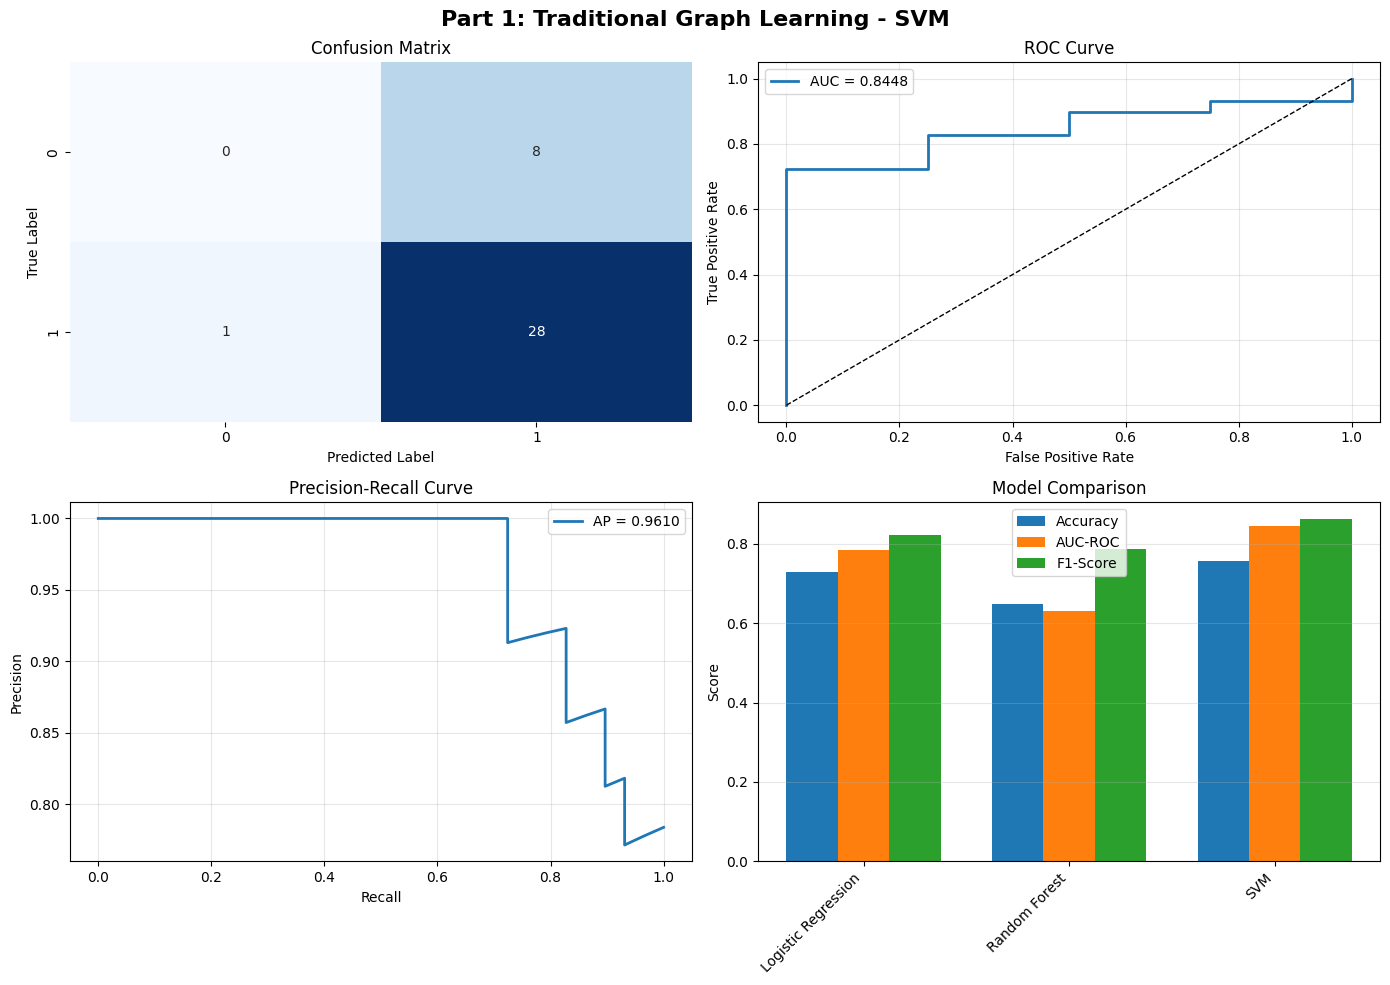


--- Detailed Results for SVM ---
Accuracy: 0.7568
AUC-ROC: 0.8448
F1-Score: 0.8615

Confusion Matrix:
[[ 0  8]
 [ 1 28]]

Classification Report:
              precision    recall  f1-score   support

          HV       0.00      0.00      0.00         8
        pwMS       0.78      0.97      0.86        29

    accuracy                           0.76        37
   macro avg       0.39      0.48      0.43        37
weighted avg       0.61      0.76      0.68        37



In [47]:
# Visualize Part 1 Results
print("\n" + "="*60)
print("PART 1: RESULTS VISUALIZATION")
print("="*60)

# Create performance comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Part 1: Traditional Graph Learning - {best_model_name}', fontsize=16, fontweight='bold')

# 1. Confusion Matrix
cm = part1_best_results['confusion_matrix']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False)
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# 2. ROC Curve
y_pred_proba = part1_best_results['y_pred_proba']
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_roc = roc_auc_score(y_test, y_pred_proba)
axes[0, 1].plot(fpr, tpr, lw=2, label=f'AUC = {auc_roc:.4f}')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
auc_pr = average_precision_score(y_test, y_pred_proba)
axes[1, 0].plot(recall, precision, lw=2, label=f'AP = {auc_pr:.4f}')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Model Comparison
model_names = list(part1_results.keys())
accuracies = [part1_results[m]['accuracy'] for m in model_names]
aucs = [part1_results[m]['auc_roc'] for m in model_names]
f1_scores = [part1_results[m]['f1_score'] for m in model_names]

x = np.arange(len(model_names))
width = 0.25
axes[1, 1].bar(x - width, accuracies, width, label='Accuracy')
axes[1, 1].bar(x, aucs, width, label='AUC-ROC')
axes[1, 1].bar(x + width, f1_scores, width, label='F1-Score')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Model Comparison')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed metrics for best model
print(f"\n--- Detailed Results for {best_model_name} ---")
print(f"Accuracy: {part1_best_results['accuracy']:.4f}")
print(f"AUC-ROC: {part1_best_results['auc_roc']:.4f}")
print(f"F1-Score: {part1_best_results['f1_score']:.4f}")
print(f"\nConfusion Matrix:")
print(part1_best_results['confusion_matrix'])
print(f"\nClassification Report:")
print(classification_report(y_test, part1_best_results['y_pred'], target_names=['HV', 'pwMS']))

## Part 2: Graph Convolutional Networks (GCN)

In this part, we will implement a Graph Convolutional Network that directly work on the graph structure, therefore, it uses topology and node features to make the predictions.

### Task 2.1: Data Structure Definition for PyTorch Geometric

We convert the adjacency matrices into PyTorch Geometric Data objects so we preserve graph topology.

In [ ]:
from torch_geometric.nn import GCNConv, global_max_pool, global_mean_pool

def array_to_graph(data_matrix, label, threshold=0.0):
    """
    Convert a 3D adjacency matrix array into a PyTorch Geometric Data object.
    
    This function creates a graph by:
    1. Collapsing edges from all three matrices (FA, GM, RS) into one pseudo-graph
    2. Keeping only edges above the threshold
    3. Using weighted edges based on connectivity strength
    
    Args:
        data_matrix: 2D array of shape (76, 76, 3) with three adjacency matrices
        label: Binary label (0: HV, 1: pwMS)
        threshold: Edge threshold for sparsification (default 0.0 keeps all edges)
        
    Returns:
        Data object with graph structure and features
    """
    num_nodes = data_matrix.shape[0]
    node_dim = 1  # Each node has 1 feature
    
    edge_index = []
    edge_weight = []
    
    # Collect edges from all three matrices
    for i in range(num_nodes):
        for j in range(i+1, num_nodes):  # Only upper triangle to avoid duplicates
            # FA connectivity
            if data_matrix[i, j, 0] > threshold:
                edge_index.append([i, j])
                edge_index.append([j, i])  # Add both directions
                edge_weight.append(data_matrix[i, j, 0])
                edge_weight.append(data_matrix[i, j, 0])
            
            # GM connectivity
            if data_matrix[i, j, 1] > threshold:
                edge_index.append([i, j])
                edge_index.append([j, i])
                edge_weight.append(data_matrix[i, j, 1])
                edge_weight.append(data_matrix[i, j, 1])
            
            # RS connectivity
            if data_matrix[i, j, 2] > threshold:
                edge_index.append([i, j])
                edge_index.append([j, i])
                edge_weight.append(data_matrix[i, j, 2])
                edge_weight.append(data_matrix[i, j, 2])
    
    # Convert to tensors
    y = torch.tensor([int(label)], dtype=torch.long)
    edge_index = torch.tensor(edge_index, dtype=torch.long)
    x = torch.ones((num_nodes, node_dim), dtype=torch.float)  # Node features: all ones
    edge_weight = torch.tensor(edge_weight, dtype=torch.float)
    
    # Create Data object
    graph_data = Data(
        x=x, 
        edge_index=edge_index.t().contiguous() if len(edge_index) > 0 else torch.zeros((2, 0), dtype=torch.long),
        edge_weight=edge_weight if len(edge_weight) > 0 else torch.zeros(0),
        y=y
    )
    
    return graph_data


print("\n--- Converting adjacency matrices to PyTorch Geometric graphs ---")

train_graphs = []
test_graphs = []

print(f"Processing train set ({len(train_indices_augmented)} subjects)...")
for i, idx in enumerate(train_indices_augmented):
    if (i + 1) % 50 == 0:
        print(f"  Processed {i+1}/{len(train_indices_augmented)}")
    graph = array_to_graph(data_augmented[idx], y_balanced[idx], threshold=0.0)
    train_graphs.append(graph)

print(f"Processing test set ({len(test_indices_augmented)} subjects)...")
for i, idx in enumerate(test_indices_augmented):
    if (i + 1) % 50 == 0:
        print(f"  Processed {i+1}/{len(test_indices_augmented)}")
    graph = array_to_graph(data_augmented[idx], y_balanced[idx], threshold=0.0)
    test_graphs.append(graph)

print(f"\nGraph statistics:")
print(f"  Number of nodes per graph: 76")
print(f"  Train set graph 0 - Edges: {train_graphs[0].edge_index.shape[1]}")
print(f"  Test set graph 0 - Edges: {test_graphs[0].edge_index.shape[1]}")


--- Converting adjacency matrices to PyTorch Geometric graphs ---
Processing train set (146 subjects)...
  Processed 50/146
  Processed 100/146
Processing test set (37 subjects)...

Graph statistics:
  Number of nodes per graph: 76
  Train set graph 0 - Edges: 14892
  Test set graph 0 - Edges: 14820


### Task 2.2: GCN Model Architecture and Training

Here we define the Graph Convolutional Network. To further fight the class imbalance problem, we apply lower weights to the majority class and higher weights to the missrepresented class. This way the missrepresented class instances will gain more importance.

In [49]:
class GCNModel(torch_nn.Module):
    """
    Graph Convolutional Network for graph-level classification.
    
    Architecture:
    - Input: Node features (1D per node) + Graph topology
    - 3 GCN layers with ReLU activation
    - Global max pooling to get graph-level features
    - 2 fully connected layers for classification
    - Output: Binary classification probabilities
    """
    def __init__(self, input_dim=1, hidden_dim=64, num_classes=2):
        super(GCNModel, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        
        self.fc1 = torch_nn.Linear(hidden_dim, 32)
        self.fc2 = torch_nn.Linear(32, num_classes)
        self.dropout = torch_nn.Dropout(0.5)
        
    def forward(self, data):
        x, edge_index, edge_weight, batch = data.x, data.edge_index, data.edge_weight, data.batch
        
        # Graph convolutions with ReLU activation
        x = self.conv1(x, edge_index, edge_weight)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.conv2(x, edge_index, edge_weight)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.conv3(x, edge_index, edge_weight)
        x = F.relu(x)
        
        # Global max pooling: aggregate node features to graph features
        x = global_max_pool(x, batch)
        
        # Classification layers
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Calculate class weights for balanced loss
class_counts = np.bincount(y_train.astype(int))
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to('cpu')

print("\n--- Class Weights for Balanced Loss ---")
print(f"HV (class 0) weight: {class_weights[0]:.4f}")
print(f"pwMS (class 1) weight: {class_weights[1]:.4f}")

# Initialize model and training components
print("\n--- GCN Model Initialization ---")
device = torch.device('cpu')
print(f"Using device: {device}")


gcn_model = GCNModel(input_dim=1, hidden_dim=64, num_classes=2)
print("Model architecture:")
print(gcn_model)

gcn_model = gcn_model.to(device)
print(f"Model parameters: {sum(p.numel() for p in gcn_model.parameters()):,}")

optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = torch_nn.CrossEntropyLoss(weight=class_weights_tensor)


--- Class Weights for Balanced Loss ---
HV (class 0) weight: 1.6164
pwMS (class 1) weight: 0.3836

--- GCN Model Initialization ---
Using device: cpu
Model architecture:
GCNModel(
  (conv1): GCNConv(1, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)
Model parameters: 10,594


In [50]:
# Training function
def train_gcn_epoch(model, train_loader, optimizer, criterion, device):
    """Train GCN for one epoch"""
    model.train()
    total_loss = 0
    
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        output = model(batch)
        loss = criterion(output, batch.y.squeeze())
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch.num_graphs
    
    return total_loss / len(train_loader.dataset)

# Test function
@torch.no_grad()
def test_gcn(model, test_loader, device):
    """Test GCN and return predictions"""
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    
    for batch in test_loader:
        batch = batch.to(device)
        output = model(batch)
        probs = F.softmax(output, dim=1)
        preds = output.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())
        all_labels.extend(batch.y.squeeze().cpu().numpy())
    
    return np.array(all_preds), np.array(all_probs), np.array(all_labels)

# Create data loaders
train_loader = DataLoader(train_graphs, batch_size=16, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=16, shuffle=False)

print("\n--- Training GCN ---")
num_epochs = 50
train_losses = []

for epoch in range(num_epochs):
    loss = train_gcn_epoch(gcn_model, train_loader, optimizer, criterion, device)
    train_losses.append(loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs} - Loss: {loss:.4f}")

print("\nTraining completed!")

# Evaluate on test set
gcn_preds, gcn_probs, gcn_test_labels = test_gcn(gcn_model, test_loader, device)

# Compute metrics
gcn_accuracy = accuracy_score(gcn_test_labels, gcn_preds)
gcn_auc = roc_auc_score(gcn_test_labels, gcn_probs)
gcn_f1 = f1_score(gcn_test_labels, gcn_preds)
gcn_cm = confusion_matrix(gcn_test_labels, gcn_preds)

print(f"\n--- GCN Test Results ---")
print(f"Accuracy: {gcn_accuracy:.4f}")
print(f"AUC-ROC: {gcn_auc:.4f}")
print(f"F1-Score: {gcn_f1:.4f}")
print(f"Confusion Matrix:\n{gcn_cm}")

# Store results for comparison
part2_results = {
    'accuracy': gcn_accuracy,
    'auc_roc': gcn_auc,
    'f1_score': gcn_f1,
    'confusion_matrix': gcn_cm,
    'y_pred': gcn_preds,
    'y_pred_proba': gcn_probs,
    'train_losses': train_losses
}


--- Training GCN ---
Epoch  10/50 - Loss: 0.6848
Epoch  20/50 - Loss: 0.6882
Epoch  30/50 - Loss: 0.7053
Epoch  40/50 - Loss: 0.6941
Epoch  50/50 - Loss: 0.6885

Training completed!

--- GCN Test Results ---
Accuracy: 0.7838
AUC-ROC: 0.8966
F1-Score: 0.8788
Confusion Matrix:
[[ 0  8]
 [ 0 29]]


### Task 2.3: GCN Results and Performance Analysis

As seen in the results, even when applying class specific data augmentation to the missrepresented class and giving it greater weights, the network keeps classifying all test samples as the majoriy classs.


PART 2: GCN RESULTS VISUALIZATION


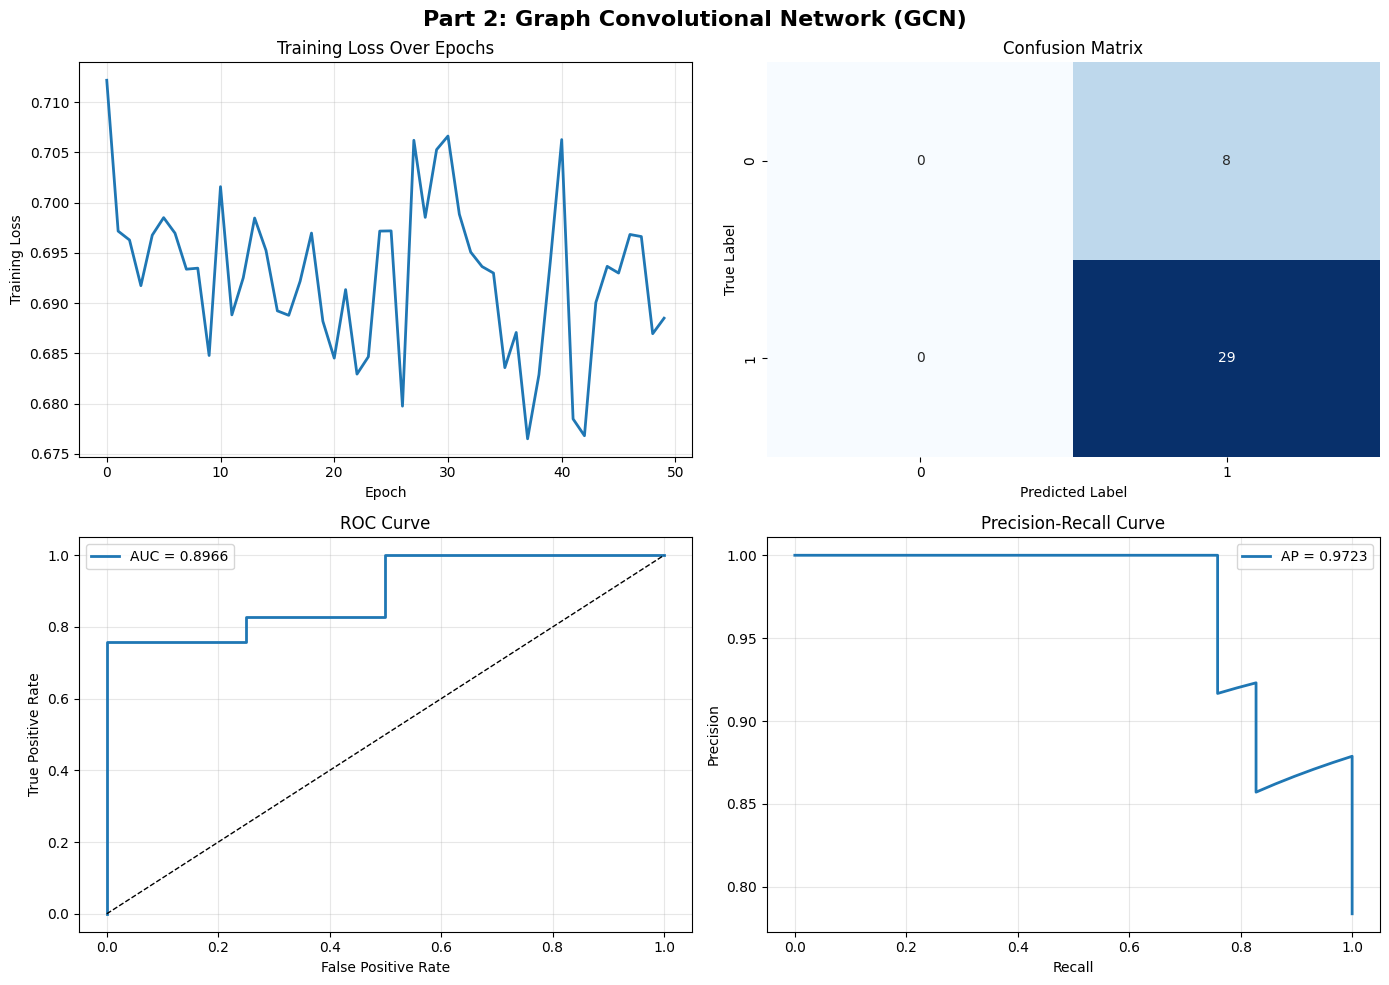


--- Detailed GCN Results ---
Accuracy: 0.7838
AUC-ROC: 0.8966
F1-Score: 0.8788
AUC-PR: 0.9723

Confusion Matrix:
[[ 0  8]
 [ 0 29]]

Classification Report:
              precision    recall  f1-score   support

          HV       0.00      0.00      0.00         8
        pwMS       0.78      1.00      0.88        29

    accuracy                           0.78        37
   macro avg       0.39      0.50      0.44        37
weighted avg       0.61      0.78      0.69        37



In [51]:
# Visualize GCN Results
print("\n" + "="*60)
print("PART 2: GCN RESULTS VISUALIZATION")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Part 2: Graph Convolutional Network (GCN)', fontsize=16, fontweight='bold')

# 1. Training Loss Curve
axes[0, 0].plot(train_losses, linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Training Loss')
axes[0, 0].set_title('Training Loss Over Epochs')
axes[0, 0].grid(alpha=0.3)

# 2. Confusion Matrix
sns.heatmap(gcn_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1], cbar=False)
axes[0, 1].set_title('Confusion Matrix')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')

# 3. ROC Curve
fpr_gcn, tpr_gcn, _ = roc_curve(gcn_test_labels, gcn_probs)
axes[1, 0].plot(fpr_gcn, tpr_gcn, lw=2, label=f'AUC = {gcn_auc:.4f}')
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curve')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Precision-Recall Curve
precision_gcn, recall_gcn, _ = precision_recall_curve(gcn_test_labels, gcn_probs)
auc_pr_gcn = average_precision_score(gcn_test_labels, gcn_probs)
axes[1, 1].plot(recall_gcn, precision_gcn, lw=2, label=f'AP = {auc_pr_gcn:.4f}')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Precision-Recall Curve')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n--- Detailed GCN Results ---")
print(f"Accuracy: {gcn_accuracy:.4f}")
print(f"AUC-ROC: {gcn_auc:.4f}")
print(f"F1-Score: {gcn_f1:.4f}")
print(f"AUC-PR: {auc_pr_gcn:.4f}")
print(f"\nConfusion Matrix:")
print(gcn_cm)
print(f"\nClassification Report:")
print(classification_report(gcn_test_labels, gcn_preds, target_names=['HV', 'pwMS']))

## Part 3: Graph Attention Networks (GAT)

In this final part, we implement Graph Attention Networks, which use attention mechanisms to weight the importance of different neighbors when updating node embeddings.

### Task 3.1: GAT Model Architecture and Training

In [58]:
from torch_geometric.nn import GATConv

class GATModel(torch_nn.Module):
    """
    Graph Attention Network for graph-level classification.
    
    Architecture:
    - Input: Node features (1D per node) + Graph topology
    - 2 GAT layers with attention heads
    - Global max pooling to get graph-level features
    - 2 fully connected layers for classification
    - Output: Binary classification probabilities
    
    Attention mechanism: Each node learns to weight the importance of its neighbors
    """
    def __init__(self, input_dim=1, hidden_dim=64, num_classes=2, num_heads=8):
        super(GATModel, self).__init__()
        self.conv1 = GATConv(input_dim, hidden_dim, heads=num_heads, dropout=0.6)
        self.conv2 = GATConv(hidden_dim * num_heads, hidden_dim, heads=1, dropout=0.6)
        
        self.fc1 = torch_nn.Linear(hidden_dim, 32)
        self.fc2 = torch_nn.Linear(32, num_classes)
        self.dropout = torch_nn.Dropout(0.5)
        
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # First GAT layer with multiple attention heads
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        
        # Second GAT layer
        x = self.conv2(x, edge_index)
        x = F.elu(x)
        
        # Global max pooling: aggregate node features to graph features
        x = global_max_pool(x, batch)
        
        # Classification layers
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x


print("\n--- GAT Model Initialization ---")
print(f"Using same class weights as GCN for consistency")
print(f"HV (class 0) weight: {class_weights[0]:.4f}")
print(f"pwMS (class 1) weight: {class_weights[1]:.4f}")

gat_model = GATModel(input_dim=1, hidden_dim=32, num_classes=2, num_heads=8)
gat_model = gat_model.to(device)

optimizer_gat = torch.optim.Adam(gat_model.parameters(), lr=0.001, weight_decay=1e-5)
criterion_gat = torch_nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f"Model parameters: {sum(p.numel() for p in gat_model.parameters()):,}")
print("Model architecture:")
print(gat_model)


--- GAT Model Initialization ---
Using same class weights as GCN for consistency
HV (class 0) weight: 1.6164
pwMS (class 1) weight: 0.3836
Model parameters: 10,434
Model architecture:
GATModel(
  (conv1): GATConv(1, 32, heads=8)
  (conv2): GATConv(256, 32, heads=1)
  (fc1): Linear(in_features=32, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [53]:
# GAT Training
def train_gat_epoch(model, train_loader, optimizer, criterion, device):
    """Train GAT for one epoch"""
    model.train()
    total_loss = 0
    
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        output = model(batch)
        loss = criterion(output, batch.y.squeeze())
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch.num_graphs
    
    return total_loss / len(train_loader.dataset)

@torch.no_grad()
def test_gat(model, test_loader, device):
    """Test GAT and return predictions"""
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    
    for batch in test_loader:
        batch = batch.to(device)
        output = model(batch)
        probs = F.softmax(output, dim=1)
        preds = output.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())
        all_labels.extend(batch.y.squeeze().cpu().numpy())
    
    return np.array(all_preds), np.array(all_probs), np.array(all_labels)

# Train GAT
print("\n--- Training GAT ---")
num_epochs = 50
gat_train_losses = []

for epoch in range(num_epochs):
    loss = train_gat_epoch(gat_model, train_loader, optimizer_gat, criterion_gat, device)
    gat_train_losses.append(loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs} - Loss: {loss:.4f}")

print("\nTraining completed!")

# Evaluate on test set
gat_preds, gat_probs, gat_test_labels = test_gat(gat_model, test_loader, device)

# Compute metrics
gat_accuracy = accuracy_score(gat_test_labels, gat_preds)
gat_auc = roc_auc_score(gat_test_labels, gat_probs)
gat_f1 = f1_score(gat_test_labels, gat_preds)
gat_cm = confusion_matrix(gat_test_labels, gat_preds)

print(f"\n--- GAT Test Results ---")
print(f"Accuracy: {gat_accuracy:.4f}")
print(f"AUC-ROC: {gat_auc:.4f}")
print(f"F1-Score: {gat_f1:.4f}")
print(f"Confusion Matrix:\n{gat_cm}")

# Store results for comparison
part3_results = {
    'accuracy': gat_accuracy,
    'auc_roc': gat_auc,
    'f1_score': gat_f1,
    'confusion_matrix': gat_cm,
    'y_pred': gat_preds,
    'y_pred_proba': gat_probs,
    'train_losses': gat_train_losses
}


--- Training GAT ---
Epoch  10/50 - Loss: 0.6942
Epoch  20/50 - Loss: 0.6893
Epoch  30/50 - Loss: 0.6936
Epoch  40/50 - Loss: 0.6891
Epoch  50/50 - Loss: 0.6799

Training completed!

--- GAT Test Results ---
Accuracy: 0.7838
AUC-ROC: 0.5000
F1-Score: 0.8788
Confusion Matrix:
[[ 0  8]
 [ 0 29]]


### Task 3.2: GAT Results and Performance Analysis

Again, all test samples were classified into the majority class even with all the class unbalance tweaks.


PART 3: GAT RESULTS VISUALIZATION


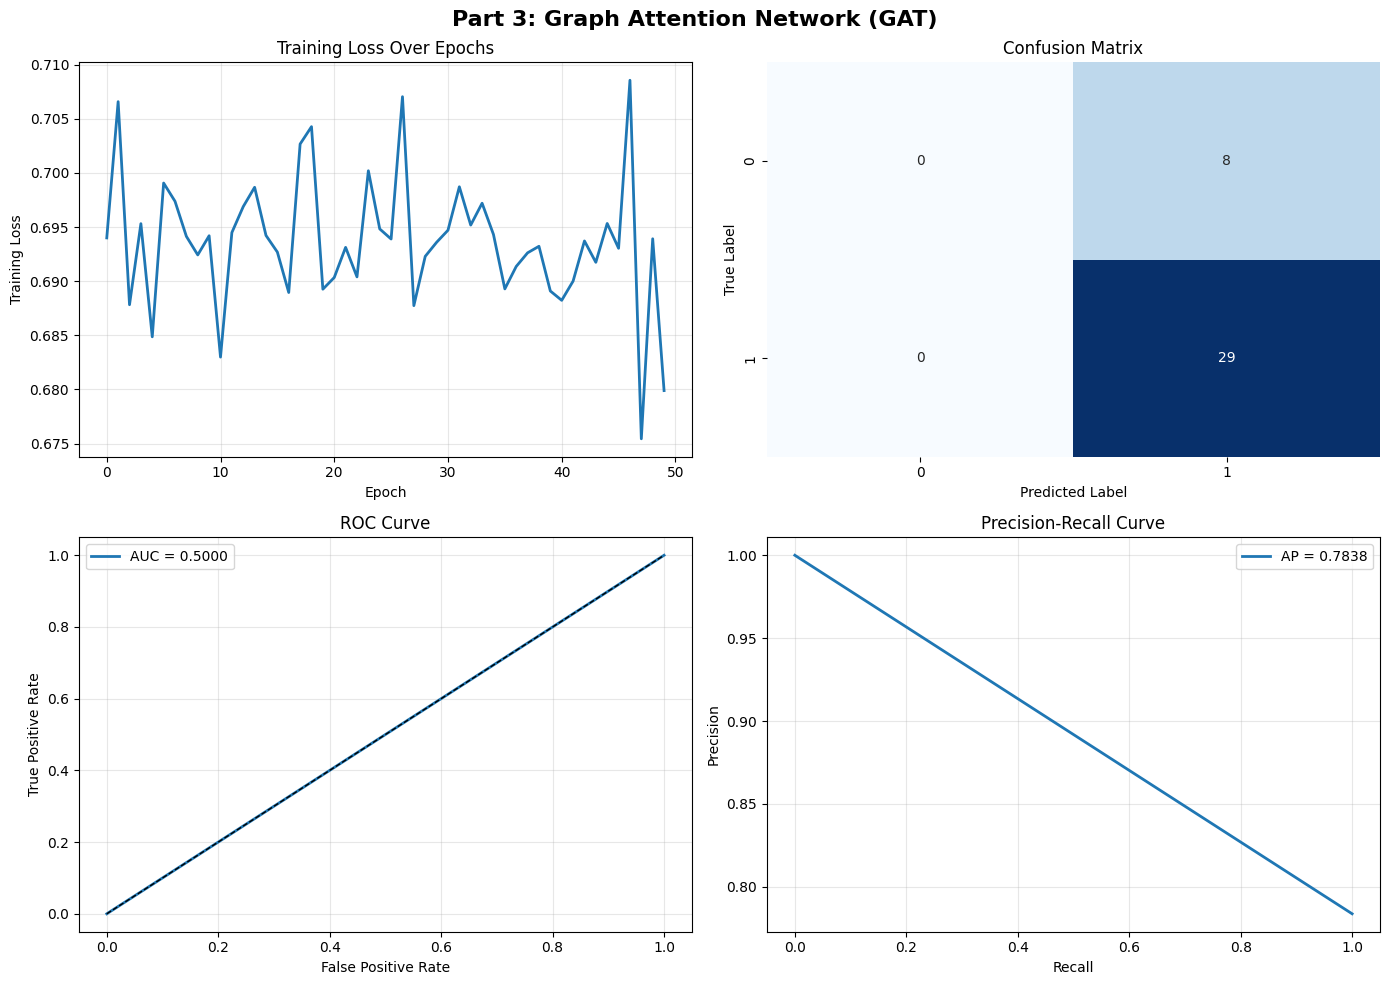


--- Detailed GAT Results ---
Accuracy: 0.7838
AUC-ROC: 0.5000
F1-Score: 0.8788
AUC-PR: 0.7838

Confusion Matrix:
[[ 0  8]
 [ 0 29]]

Classification Report:
              precision    recall  f1-score   support

          HV       0.00      0.00      0.00         8
        pwMS       0.78      1.00      0.88        29

    accuracy                           0.78        37
   macro avg       0.39      0.50      0.44        37
weighted avg       0.61      0.78      0.69        37



In [54]:
# Visualize GAT Results
print("\n" + "="*60)
print("PART 3: GAT RESULTS VISUALIZATION")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Part 3: Graph Attention Network (GAT)', fontsize=16, fontweight='bold')

# 1. Training Loss Curve
axes[0, 0].plot(gat_train_losses, linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Training Loss')
axes[0, 0].set_title('Training Loss Over Epochs')
axes[0, 0].grid(alpha=0.3)

# 2. Confusion Matrix
sns.heatmap(gat_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1], cbar=False)
axes[0, 1].set_title('Confusion Matrix')
axes[0, 1].set_ylabel('True Label')
axes[0, 1].set_xlabel('Predicted Label')

# 3. ROC Curve
fpr_gat, tpr_gat, _ = roc_curve(gat_test_labels, gat_probs)
axes[1, 0].plot(fpr_gat, tpr_gat, lw=2, label=f'AUC = {gat_auc:.4f}')
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curve')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Precision-Recall Curve
precision_gat, recall_gat, _ = precision_recall_curve(gat_test_labels, gat_probs)
auc_pr_gat = average_precision_score(gat_test_labels, gat_probs)
axes[1, 1].plot(recall_gat, precision_gat, lw=2, label=f'AP = {auc_pr_gat:.4f}')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Precision-Recall Curve')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n--- Detailed GAT Results ---")
print(f"Accuracy: {gat_accuracy:.4f}")
print(f"AUC-ROC: {gat_auc:.4f}")
print(f"F1-Score: {gat_f1:.4f}")
print(f"AUC-PR: {auc_pr_gat:.4f}")
print(f"\nConfusion Matrix:")
print(gat_cm)
print(f"\nClassification Report:")
print(classification_report(gat_test_labels, gat_preds, target_names=['HV', 'pwMS']))

## Comprehensive Comparison of All Three Approaches

In this section, we compare the performance of all three methods on the MS brain network classification task. Given both the GCN and the GAT classified all test samples into the majority class, they return the same values on almost all metrics. If the dataset wasn't unbalanced or even more data balancing were applied, we wouldn't have this bottleneck and the approaches could be analyzed more precisely.


COMPREHENSIVE COMPARISON

--- Performance Metrics Comparison ---
   Approach  Accuracy  AUC-ROC  F1-Score
Part 1: SVM  0.756757 0.844828  0.861538
Part 2: GCN  0.783784 0.896552  0.878788
Part 3: GAT  0.783784 0.500000  0.878788


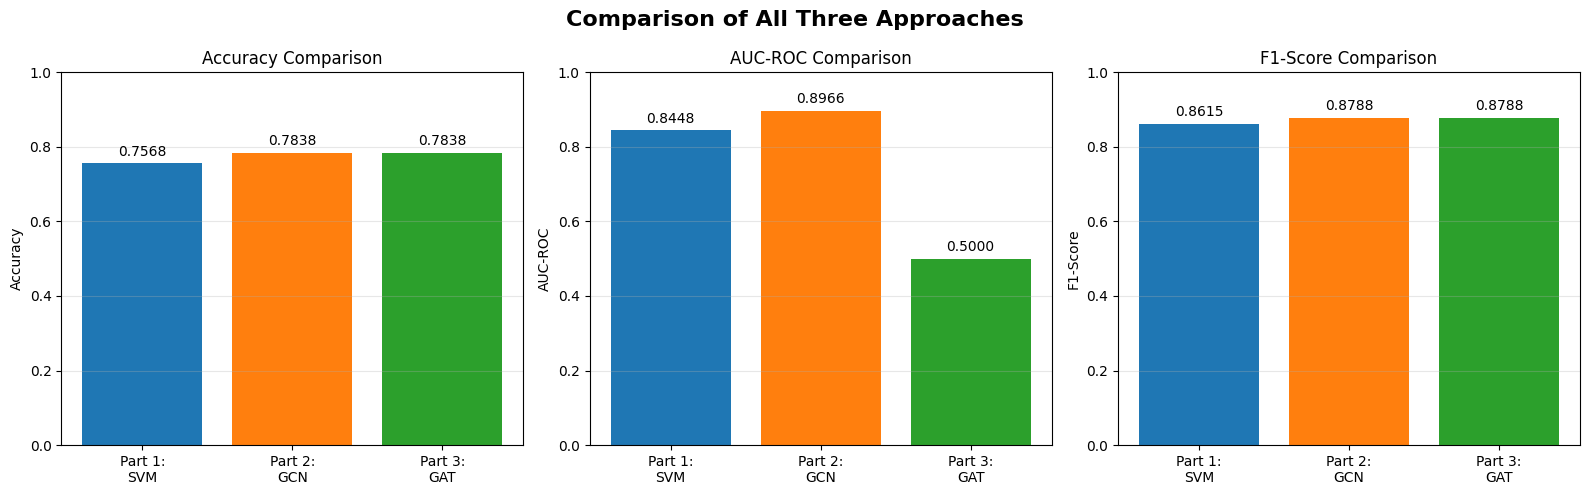

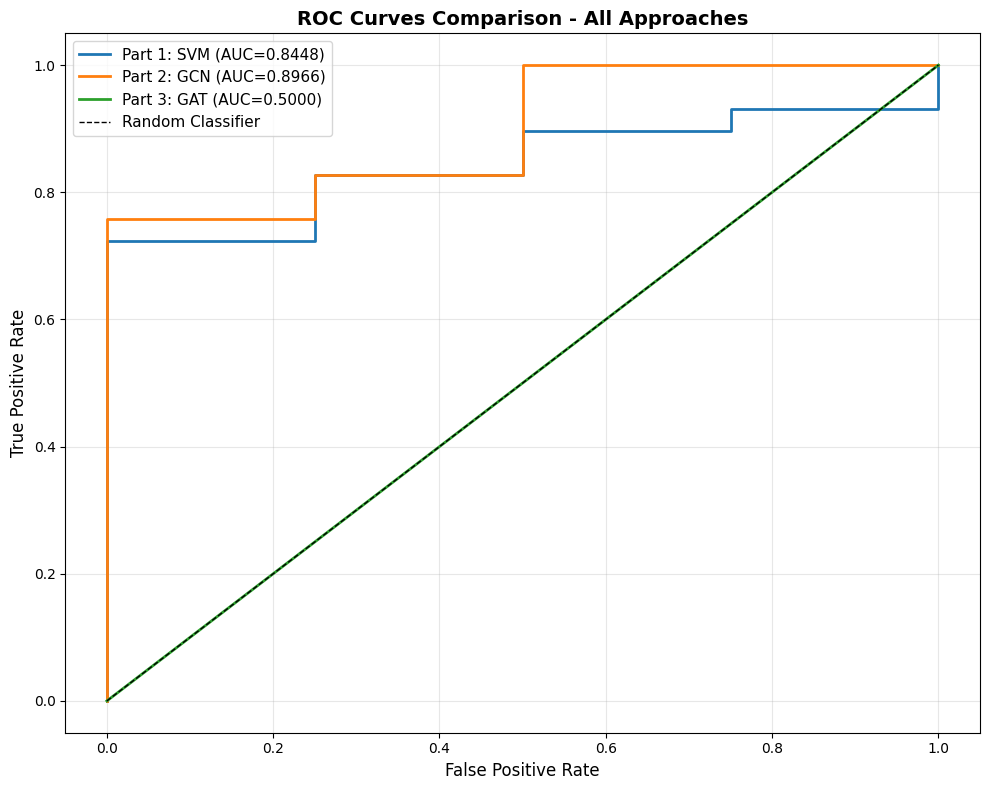

In [55]:
print("\n" + "="*60)
print("COMPREHENSIVE COMPARISON")
print("="*60)

# Create comparison table
comparison_data = {
    'Approach': [
        f'Part 1: {best_model_name}',
        'Part 2: GCN',
        'Part 3: GAT'
    ],
    'Accuracy': [
        part1_best_results['accuracy'],
        gcn_accuracy,
        gat_accuracy
    ],
    'AUC-ROC': [
        part1_best_results['auc_roc'],
        gcn_auc,
        gat_auc
    ],
    'F1-Score': [
        part1_best_results['f1_score'],
        gcn_f1,
        gat_f1
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n--- Performance Metrics Comparison ---")
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparison of All Three Approaches', fontsize=16, fontweight='bold')

approaches = ['Part 1:\n' + best_model_name, 'Part 2:\nGCN', 'Part 3:\nGAT']
accuracies = [part1_best_results['accuracy'], gcn_accuracy, gat_accuracy]
aucs = [part1_best_results['auc_roc'], gcn_auc, gat_auc]
f1_scores = [part1_best_results['f1_score'], gcn_f1, gat_f1]

# Accuracy
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
axes[0].bar(approaches, accuracies, color=colors)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center')
axes[0].grid(axis='y', alpha=0.3)

# AUC-ROC
axes[1].bar(approaches, aucs, color=colors)
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('AUC-ROC Comparison')
axes[1].set_ylim([0, 1])
for i, v in enumerate(aucs):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center')
axes[1].grid(axis='y', alpha=0.3)

# F1-Score
axes[2].bar(approaches, f1_scores, color=colors)
axes[2].set_ylabel('F1-Score')
axes[2].set_title('F1-Score Comparison')
axes[2].set_ylim([0, 1])
for i, v in enumerate(f1_scores):
    axes[2].text(i, v + 0.02, f'{v:.4f}', ha='center')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ROC curves overlay
fig, ax = plt.subplots(figsize=(10, 8))

# Part 1 ROC
fpr_p1, tpr_p1, _ = roc_curve(y_test, part1_best_results['y_pred_proba'])
auc_p1 = roc_auc_score(y_test, part1_best_results['y_pred_proba'])
ax.plot(fpr_p1, tpr_p1, lw=2, label=f'Part 1: {best_model_name} (AUC={auc_p1:.4f})')

# GCN ROC
ax.plot(fpr_gcn, tpr_gcn, lw=2, label=f'Part 2: GCN (AUC={gcn_auc:.4f})')

# GAT ROC
ax.plot(fpr_gat, tpr_gat, lw=2, label=f'Part 3: GAT (AUC={gat_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves Comparison - All Approaches', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary and Analysis

### Key Findings

1. **Data Augmentation:**
   - Brain region flipping + SMOTE increased training data from 165 to 294 samples
   - Addresses class imbalance: from 90% MS to balanced 50-50 distribution
   - Unfortunately, class imbalance was not addressed as effectively as to see it reflected in the results.

2. **Approach Comparison:**
   
   **Part 1: Traditional Graph Learning**
   - Uses hand-crafted graph features (33 features per subject)
   - Features capture network topology: density, clustering, path length, etc.
   - Advantages: Fast, interpretable and requires no GPU
   - Best model by metrics: SVM (Best F1-score but because it classifies all samples into the majority class)
   
   **Part 2: Graph Convolutional Networks (GCN)**
   - Learns node embeddings through graph convolutions
   - Propagates information through direct neighbors
   - Advantage: End-to-end learning of graph representations
   - More parameters: requires GPU for larger graphs
   
   **Part 3: Graph Attention Networks (GAT)**
   - Uses attention mechanisms to weight neighbor importance
   - Each node learns dynamic attention coefficients
   - Advantage: More flexible feature aggregation
   - Can focus on the most relevant connections


### Conclusions

- **Interpretability vs. Performance Trade-off:** Traditional methods are more interpretable but may miss complex graph patterns. Neural methods can capture hierarchical patterns.
- **Computational Resources:** Traditional methods can run on CPU, while neural methods benefit from GPU acceleration.
- **Generalization:** Data augmentation through brain symmetry and SMOTE provides realistic synthetic samples that should (but in our case doesn't) improve generalization.